# Quads design (3dp pla + blue shims) for nonlinear waves cloaking of void inclusion


## Imports

In [ ]:
import os

os.environ["XLA_FLAGS"] = (
    "--xla_force_host_platform_device_count=8"  # Use 8 CPU cores for JAX pmap
)

import matplotlib
import matplotlib.pyplot as plt
import jax.numpy as jnp
import jax
from pathlib import Path
from problems.quads_dynamic_cloaking import (
    ForwardInput,
    ForwardProblem,
    OptimizationProblem,
)
from mechanicalmetamaterialcloaks.geometry import (
    QuadGeometry,
    CloakQuadGeometry,
    compute_xy_limits,
)
from mechanicalmetamaterialcloaks.utils import load_data, save_data, SolutionData
from mechanicalmetamaterialcloaks.plotting import (
    plot_geometry_field_overlaid, plot_geometry,
    generate_several_animations_with_traces
)

jax.config.update("jax_enable_x64", True)  # enable float64 type

plt.style.use(["science", "grid"])
%matplotlib widget

## Paths

In [ ]:
# Where to load/save data
data_folder = Path("../data/quads_dynamic_cloaking_3dp_pla_shims")
# Where to save plots and animations
out_folder = Path("../out/quads_dynamic_cloaking_3dp_pla_shims")

## Plotting and helper functions

In [ ]:
def plot_objective_iterations(optimization: OptimizationProblem, optimization_filename=None):

    fig, axes = plt.subplots(nrows=3, figsize=(10, 7), sharex=True, constrained_layout=True)
    axes[0].set(ylabel="Objective")
    axes[0].plot(optimization.objective_values, lw=3, color="#2980b9")
    axes[1].set(ylabel="Angle constraints violation")
    axes[1].plot(optimization.constraints_violation["angles"], lw=3, color="#c0392b")
    axes[1].axhline(y=0, color="black")
    axes[2].set(ylabel="Edge length constraints violation")
    axes[2].plot(optimization.constraints_violation["edge_lengths"], lw=3, color="#c0392b")
    axes[2].axhline(y=0, color="black")
    axes[-1].set(xlabel="Iteration")

    if optimization_filename is not None:
        path = Path(
            out_folder / optimization_filename / "objective_iterations.png"
        )
        path.parent.mkdir(parents=True, exist_ok=True)  # Make sure parents directories exist
        fig.savefig(str(path), dpi=300)


def value_to_idx(x, linspace_array):
    """Return the index in the linspace_array corresponding to the value x."""
    return int(
        jnp.clip(
            (x - linspace_array[0])
            / (linspace_array[-1] - linspace_array[0])
            * (len(linspace_array) - 1),
            0,
            len(linspace_array) - 1,
        )
    )


def plot_snapshot_simulation(
    solution_data: SolutionData,
    field: str,
    time: float,
    field_values=None,
    cmap="inferno",
    figsize=(4, 4),
    xlim=None,
    ylim=None,
    vlim=None,
    ax=None,
):
    """Plot a snapshot of the simulation."""

    timepoint = value_to_idx(time, solution_data.timepoints)
    fig, axes = plot_geometry_field_overlaid(
        data=solution_data,
        field=field,
        timepoint=timepoint,
        field_values=field_values,
        deformed=True,
        cmap=cmap,
        xlim=xlim,
        ylim=ylim,
        vlim=vlim,
        colorbar=False,
        figsize=figsize,
        axis=False,
        ax=ax,
    )
    return fig, axes


def plot_boundary_field_profile(solution_datas, selected_timepoints, n1_blocks, figsize=(6, 2.5), fontsize=12, ticksize=10, linewidth=2, colors=["#2c3e50", "#ff9900", "#8e44ad"]):
    """Plot the boundary profile of the vertical displacement at selected timepoints for multiple solution data sets."""

    solution_data_reference, solution_data_holed, solution_data_cloaked = solution_datas
    alphas = jnp.linspace(0.3, 1.0, selected_timepoints.size).tolist()

    plt.close("all")
    fig, axes = plt.subplots(figsize=figsize, constrained_layout=True)
    for time, alpha in zip(selected_timepoints, alphas):
        timepoint_idx = value_to_idx(time, solution_data_reference.timepoints)
        # Plot reference
        axes.plot(
            jnp.arange(n1_blocks),
            solution_data_reference.fields[timepoint_idx, 0, -n1_blocks:, 1],
            color=colors[0],
            alpha=alpha,
            label="Reference",
            linewidth=linewidth,
        )
        # Plot holed
        axes.plot(
            jnp.arange(n1_blocks),
            solution_data_holed.fields[timepoint_idx, 0, -n1_blocks:, 1],
            color=colors[1],
            alpha=alpha,
            label="Altered",
            linewidth=linewidth,
        )
        # Plot cloaked
        axes.plot(
            jnp.arange(n1_blocks),
            solution_data_cloaked.fields[timepoint_idx, 0, -n1_blocks:, 1],
            color=colors[2],
            alpha=alpha,
            label="Cloaked",
            linewidth=linewidth,
        )

    axes.tick_params(labelsize=ticksize)
    axes.grid(False)
    axes.axhline(y=0, color="black", linewidth=1.0, zorder=0)
    # spines 1pt
    for spine in axes.spines.values():
        spine.set_linewidth(1.0)

    axes.set_xlabel("$x$ [\# units]", fontsize=fontsize)
    axes.set_ylabel("$u_y$ [mm]", fontsize=fontsize)
    # Add legend at the top of the first subplot
    axes.legend(
        handles=[
            plt.Line2D([0], [0], color=colors[0], linewidth=linewidth, label="Reference"),
            plt.Line2D([0], [0], color=colors[1], linewidth=linewidth, label="Altered"),
            plt.Line2D([0], [0], color=colors[2], linewidth=linewidth, label="Cloaked"),
        ],
        labels=["Reference", "Altered", "Cloaked"],
        fontsize=ticksize,
        loc="lower right",
        bbox_to_anchor=(1., 0),
        frameon=False,
    )

    return fig, axes

## Problem setup


In [15]:
# NOTE: Units are mm, N, s

# Geometrical params
n1_blocks = 24
n2_blocks = 24
spacing = 15.0  # 1.0  # 15 mm
hinge_length = 0.15 * spacing  # Same as bond length
initial_angle = 20 * jnp.pi / 180
mother_geometry = QuadGeometry(
    n1_blocks, n2_blocks, spacing=spacing, bond_length=hinge_length
)
initial_horizontal_shift, initial_vertical_shift = (
    mother_geometry.get_design_from_rotated_square(initial_angle)
)
(
    block_centroids_mg,
    centroid_node_vectors_mg,
    bond_connectivity_mg,
    reference_bond_vectors_mg,
) = mother_geometry.get_parametrization()
_init_block_centroids_mg = block_centroids_mg(
    initial_horizontal_shift, initial_vertical_shift
)

# Width strip and void
width_strip_cloak_area = 35.0 * 2
R = 10.0 * 4.2
N = 50
shift_to_left = 3
x0, y0 = spacing * (n1_blocks - shift_to_left) / 2, spacing * n2_blocks / 2 - 7.5
void = [
    [R * jnp.cos(2 * jnp.pi * k / N) + x0, R * jnp.sin(2 * jnp.pi * k / N) + y0]
    for k in range(N + 1)
]

cloaked_geometry = CloakQuadGeometry(
    mother_geometry,
    _init_block_centroids_mg,
    void,
    width_strip_cloak_area=width_strip_cloak_area,
)
block_centroids, centroid_node_vectors, bond_connectivity, reference_bond_vectors = (
    cloaked_geometry.get_parametrization()
)

# Initial guess
guessed_horizontal_shift, guessed_vertical_shift = (
    initial_horizontal_shift[cloaked_geometry.mask_horizontal_shift_allowed],
    initial_vertical_shift[cloaked_geometry.mask_vertical_shift_allowed],
)

# Mechanical params
k_stretch = 120.0  # stretching stiffness 120. N/mm
k_shear = 1.19  # shearing stiffness 1.19 N/mm
k_rot = 1.50  # rotational stiffness 1.50 Nmm
density = 6.18e-9  # Mg/mm^2
damping_scaling = 1.0
damping = (
    0.0186
    * jnp.array(
        [
            2 * (0.36125 * density * spacing**2 * k_shear) ** 0.5,
            2 * (0.36125 * density * spacing**2 * k_shear) ** 0.5,
            2 * (0.02175026 * density * spacing**4 * k_rot) ** 0.5,
        ]
    )
    * damping_scaling
)

# Dynamic excitation params
amplitude = 0.3 * spacing
loading_rate = 30.0
tau = 1 / loading_rate
input_delay = 3 * tau
n_pulses = 9
n_timepoints = 50 * n_pulses  # 50 timepoints per pulse
simulation_time = n_pulses * loading_rate**-1  # s

forward_input = ForwardInput(
    # amplitude=amplitude,  # mm
    # loading_rate=loading_rate,  # Hz
    horizontal_shifts=guessed_horizontal_shift,
    vertical_shifts=guessed_vertical_shift,
)

# Forward problem
problem = ForwardProblem(
    n1_blocks=n1_blocks,
    n2_blocks=n2_blocks,
    spacing=spacing,
    bond_length=hinge_length,
    void=void,
    width_strip_cloak_area=width_strip_cloak_area,
    horizontal_vertical_shifts_mg=None,
    initial_angle=initial_angle,
    k_stretch=k_stretch,
    k_shear=k_shear,
    k_rot=k_rot,
    density=density,
    k_contact=k_rot,
    damping_xy_factor=1.0,
    damping_rot_factor=1.0,
    min_angle=-15 * jnp.pi / 180,
    cutoff_angle=-10 * jnp.pi / 180,
    amplitude=amplitude,  # mm
    loading_rate=loading_rate,  # Hz
    tau=tau,  # s
    input_delay=input_delay,  # s
    n_pulses=n_pulses,  # number of pulses
    simulation_time=simulation_time,  # s
    n_timepoints=n_timepoints,
    name="quads_dynamic_cloaking_3dp_pla_shims",
)

# Optimization
optimization = OptimizationProblem(
    forward_problem=problem,
    forward_input=forward_input,
    name=problem.name,
)
problem_filename_prefix = f"quads{'_linearized_strains' if optimization.forward_problem.linearized_strains else ''}_{optimization.forward_problem.n1_blocks}x{optimization.forward_problem.n2_blocks}_amplitude_{optimization.forward_problem.amplitude}_initial_angle_{initial_angle*180/jnp.pi:.1f}_amplitude_{optimization.forward_problem.amplitude:.2f}_loading_rate_{optimization.forward_problem.loading_rate:.1f}"
optimization_filename = f"opt_with_angle_30_and_length_3_constraints_{problem_filename_prefix}"

# Setup forward problem
# optimization.forward_problem.setup()

## Optimization

### Import most recent optimization object


In [16]:
optimization = OptimizationProblem.from_dict(
    load_data(
        data_folder / optimization_filename / f"{optimization_filename}.pkl"
    )
)

### Run optimization

In [ ]:
# optimization.run_optimization_nlopt(
#     initial_guess=(optimization.forward_input.horizontal_shifts,
#                    optimization.forward_input.vertical_shifts),
#     # initial_guess=optimization.design_values[-1],
#     n_iterations=60,
#     min_block_angle=30*jnp.pi/180,
#     min_void_angle=0*jnp.pi/180,
#     min_edge_length=3.,  # mm
#     max_time=24*60*60,  # 12 hours
# )

# save_data(
#     data_folder / optimization_filename / f"{optimization_filename}.pkl",
#     optimization.to_dict()  # Optimization problem
# )

## Plots

### Import most recent optimization object


In [ ]:
optimization = OptimizationProblem.from_dict(
    load_data(
        data_folder / optimization_filename / f"{optimization_filename}.pkl"
    )
)

### Objective iterations


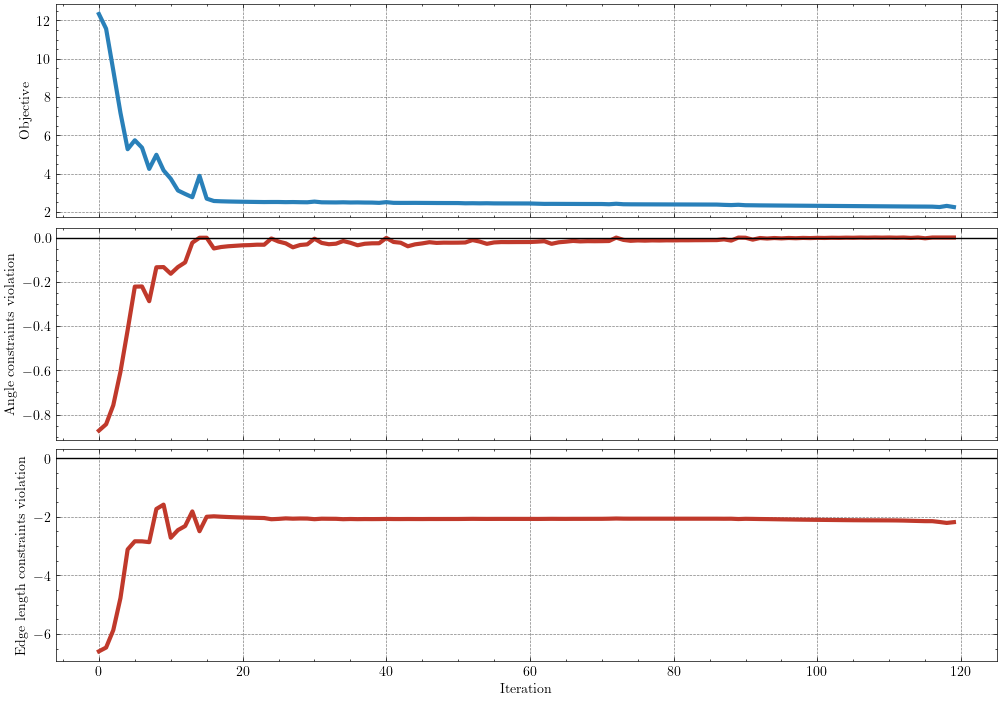

In [19]:
plot_objective_iterations(
    optimization=optimization,
    optimization_filename=optimization_filename,
)

### Plot designs


In [ ]:
for solution_data, label in zip(optimization.forward_problem.solution_data, ["intact", "holed", "cloaked"]):
    fig, axes = plot_geometry(
        block_centroids=solution_data.block_centroids,
        centroid_node_vectors=solution_data.centroid_node_vectors,
        bond_connectivity=solution_data.bond_connectivity,
        figsize=(4, 4),
    )
    axes.axis("off")
    out_path = out_folder / optimization_filename / f"{label}_geometry.png"
    out_path.parent.mkdir(parents=True, exist_ok=True)  # Make sure parents directories exist
    fig.savefig(str(out_path), dpi=300, transparent=True)
    plt.close(fig)

### Snapshots

In [21]:
solution_data_reference, solution_data_holed, solution_data_cloaked = optimization.forward_problem.solution_data

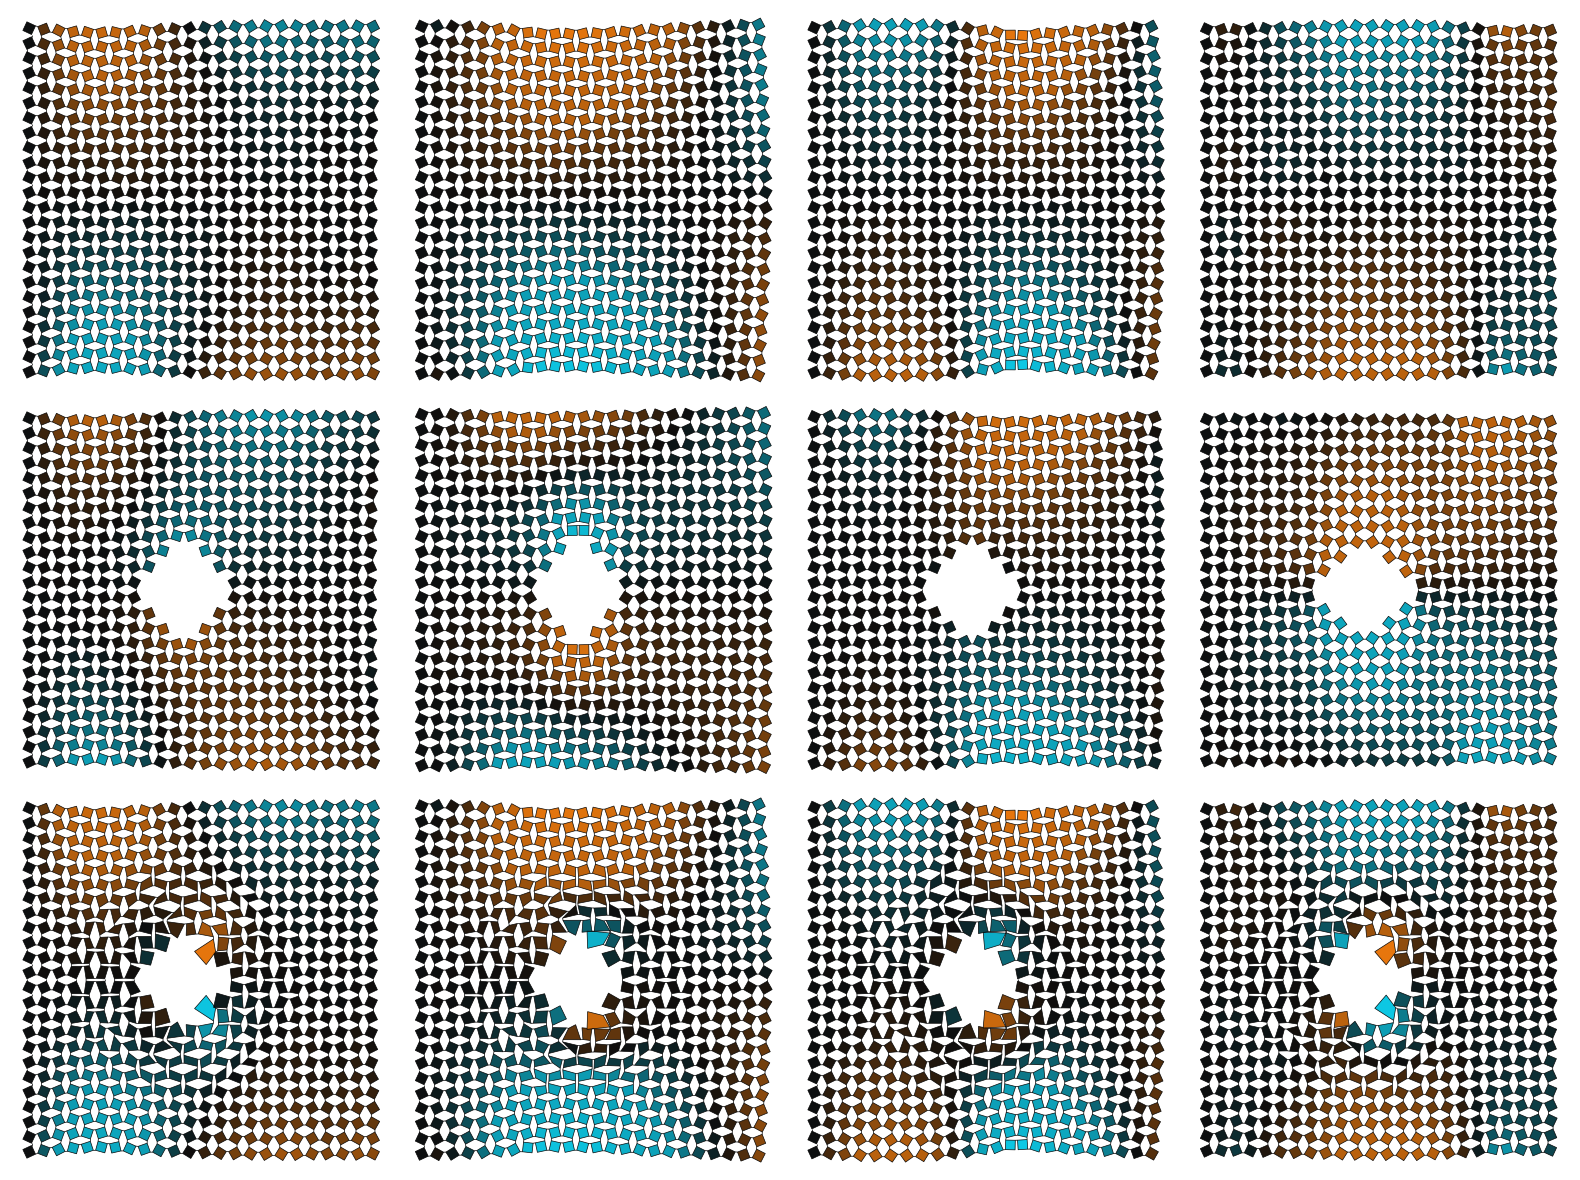

In [22]:
cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    name="custom_cmap",
    colors=[
        "#ff7b00",  # negative
        "#e46e00",  # negative
        "#c86100",  # negative
        "#b25600",  # negative
        "#000000",  # 0
        "#0098b0",  # positive
        "#00aac4",  # positive
        "#00c1df",  # positive
        "#00ddff",  # positive
    ],
)
cmap.set_bad(color="#cccccc")  # color for NaNs

# Generate figure with 3xn snapshots where n is the number of selected timepoints and 3 corresponds to the 3 solution data sets
selected_timepoints = (
    jnp.array([0.0, 0.25, 0.5, 0.75]) + optimization.forward_problem.n_pulses // 2
) * optimization.forward_problem.loading_rate**-1
vlim = (-10.0, 10.0)  # mm
plt.close("all")
fig, axes = plt.subplots(
    nrows=3,
    ncols=len(selected_timepoints),
    figsize=(4 * len(selected_timepoints), 4 * 3),
    gridspec_kw={"hspace": 0.0, "wspace": 0.0},
)
cloak_mask_reference = optimization.forward_problem.cloaked_geometry.mgIDs_cloak_area
cloak_mask_holed = optimization.forward_problem.cloaked_geometry.cgIDs_cloak_area
cloak_mask_cloaked = optimization.forward_problem.cloaked_geometry.cgIDs_cloak_area
cloak_masks = [cloak_mask_reference, cloak_mask_holed, cloak_mask_cloaked]
for i, time in enumerate(selected_timepoints):
    for data, ax, cloak_mask in zip(
        [solution_data_reference, solution_data_holed, solution_data_cloaked],
        axes[:, i],
        cloak_masks,
    ):
        field_values = data.fields[:, 0, :, 1]
        # field_values = field_values.at[:, cloak_mask].set(jnp.nan)
        plot_snapshot_simulation(
            solution_data=data,
            field="uy",
            field_values=field_values,
            time=time,
            cmap=cmap,
            vlim=vlim,
            ax=ax,
        )
for ax in axes.flatten():
    ax.axis("equal")
fig.tight_layout()
# Save figure
out_path = out_folder / optimization_filename / "snapshots_reference_holed_cloaked.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(
    out_path,
    dpi=300,
    bbox_inches="tight",
)

### Time histories

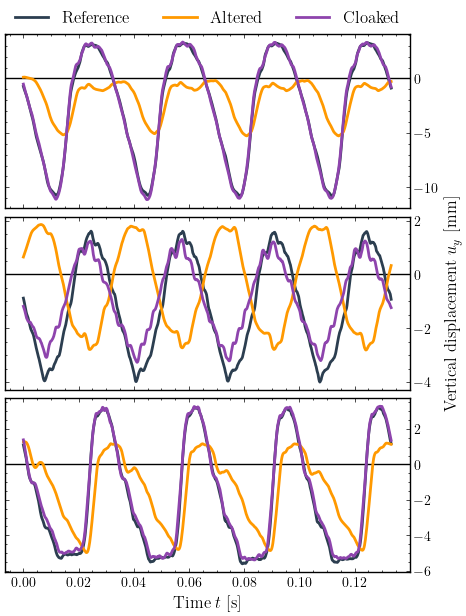

In [23]:
cdr_targeted_blocks = [
    [(n1_blocks) // 4 - 1, n2_blocks - 1],
    [(n1_blocks) // 4 - 1, 3 * n2_blocks // 4],
    [(n1_blocks) // 4 - 1, n2_blocks // 2],
    [(n1_blocks) // 2 - 1, n2_blocks - 1],
    [(n1_blocks) // 2 - 1, 3 * n2_blocks // 4],
    [3 * (n1_blocks) // 4 - 1, n2_blocks - 1],
    [3 * (n1_blocks) // 4 - 1, 3 * n2_blocks // 4],
    [3 * (n1_blocks) // 4 - 1, n2_blocks // 2],
    [7 * (n1_blocks) // 8 - 1, 3 * n2_blocks // 4],
    [7 * (n1_blocks) // 8 - 1, n2_blocks // 2],
    [(n1_blocks) - 1, 3 * n2_blocks // 4],
    [(n1_blocks) - 1, n2_blocks // 2],
]

tlim = (
    (optimization.forward_problem.n_pulses - 4)
    * optimization.forward_problem.loading_rate**-1,
    optimization.forward_problem.n_pulses
    * optimization.forward_problem.loading_rate**-1,
)
time_mask = (solution_data_reference.timepoints >= tlim[0]) & (
    solution_data_reference.timepoints <= tlim[1]
)

fontsize = 12
ticksize = 10
linewidth = 2
colors = [
    "#2c3e50",  # reference
    "#ff9900",  # holed
    "#8e44ad",  # cloaked
]

# Select blocks to plot
ks = [3, 4, 5]
# Plot time history of displacement at the selected block
plt.close("all")
fig, axes = plt.subplots(
    nrows=len(ks), figsize=(4.65, 2.05 * len(ks)), constrained_layout=True, sharex=True
)

for k, ax in zip(ks, axes):
    id_block_mg = cdr_targeted_blocks[k][0] + cdr_targeted_blocks[k][1] * n1_blocks
    id_block_cloak_area = cloaked_geometry.grid_convert_mgIDs_to_cgIDs[
        cdr_targeted_blocks[k][1], cdr_targeted_blocks[k][0]
    ]

    # Plot reference
    ax.plot(
        solution_data_reference.timepoints[time_mask]
        - solution_data_reference.timepoints[time_mask][0],
        solution_data_reference.fields[time_mask, 0, id_block_mg, 1],
        color=colors[0],
        label="Reference",
        linewidth=linewidth,
    )
    # Plot holed
    ax.plot(
        solution_data_holed.timepoints[time_mask]
        - solution_data_holed.timepoints[time_mask][0],
        solution_data_holed.fields[time_mask, 0, id_block_cloak_area, 1],
        color=colors[1],
        label="Altered",
        linewidth=linewidth,
    )
    # Plot cloaked
    ax.plot(
        solution_data_cloaked.timepoints[time_mask]
        - solution_data_cloaked.timepoints[time_mask][0],
        solution_data_cloaked.fields[time_mask, 0, id_block_cloak_area, 1],
        color=colors[2],
        label="Cloaked",
        linewidth=linewidth,
    )
    ax.tick_params(labelsize=ticksize)
    ax.grid(False)
    ax.axhline(y=0, color="black", linewidth=1.0, zorder=0)
    # spines 1pt
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
axes[-1].set_xlabel("Time $t$ [s]", fontsize=fontsize)
# Move all y labels and tick labels to the right spines
for ax in axes:
    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()
    # Keep ticks on the left side
    ax.yaxis.set_ticks_position("both")
axes[1].set_ylabel("Vertical displacement $u_y$ [mm]", fontsize=fontsize)
fig.align_ylabels()
# Add legend at the top of the first subplot
axes[0].legend(
    fontsize=fontsize,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.22),
    frameon=False,
)
# Save figure
out_path = out_folder / optimization_filename / "time_history_displacement_blocks.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(
    out_path,
    dpi=300,
    bbox_inches="tight",
)

### Field profiles on the top boundary

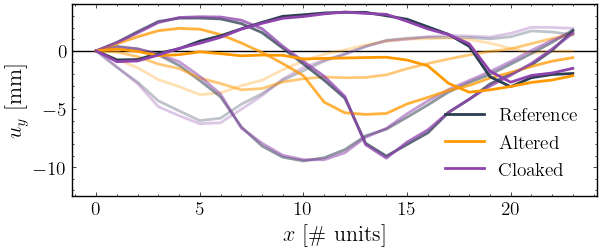

In [24]:
# Select times to plot
selected_timepoints = (jnp.array([0.0, 0.25, 0.5, 0.75]) +
                       (optimization.forward_problem.n_pulses-1)) * optimization.forward_problem.loading_rate**-1

fig, axes = plot_boundary_field_profile(
    [solution_data_reference, solution_data_holed, solution_data_cloaked], 
    selected_timepoints, 
    n1_blocks,
    fontsize=16,
    ticksize=14,
    )
axes.set_ylim(-12.5, 4)

# Save figure
out_path = out_folder / optimization_filename / "profile_top_boundary_displacement_uy.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(
    out_path,
    dpi=300,
    bbox_inches="tight",
)

## Animation: Reference vs Voided vs Cloaked

In [ ]:
cdr_targeted_blocks = [
    [(n1_blocks) // 4 - 1, n2_blocks - 1],
    [(n1_blocks) // 4 - 1, 3 * n2_blocks // 4],
    [(n1_blocks) // 4 - 1, n2_blocks // 2],
    [(n1_blocks) // 2 - 1, n2_blocks - 1],
    [(n1_blocks) // 2 - 1, 3 * n2_blocks // 4],
    [3 * (n1_blocks) // 4 - 1, n2_blocks - 1],
    [3 * (n1_blocks) // 4 - 1, 3 * n2_blocks // 4],
    [3 * (n1_blocks) // 4 - 1, n2_blocks // 2],
    [7 * (n1_blocks) // 8 - 1, 3 * n2_blocks // 4],
    [7 * (n1_blocks) // 8 - 1, n2_blocks // 2],
    [(n1_blocks) - 1, 3 * n2_blocks // 4],
    [(n1_blocks) - 1, n2_blocks // 2],
]

vlim = (-10.0, 10.0)  # mm
tlim = (
    (optimization.forward_problem.n_pulses - 4)
    * optimization.forward_problem.loading_rate**-1,
    optimization.forward_problem.n_pulses
    * optimization.forward_problem.loading_rate**-1,
)
time_mask = (solution_data_reference.timepoints >= tlim[0]) & (
    solution_data_reference.timepoints <= tlim[1]
)

fontsize = 12
ticksize = 10
linewidth = 3
colors = [
    "#2c3e50",  # reference
    "#ff9900",  # holed
    "#8e44ad",  # cloaked
]

# Select blocks to plot
k = 3  # 3, 4, 5
id_block_mg = cdr_targeted_blocks[k][0] + cdr_targeted_blocks[k][1] * n1_blocks
id_block_cloak_area = cloaked_geometry.grid_convert_mgIDs_to_cgIDs[
    cdr_targeted_blocks[k][1], cdr_targeted_blocks[k][0]
]

cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    name="custom_cmap",
    colors=[
        "#ff7b00",  # negative
        "#e46e00",  # negative
        "#c86100",  # negative
        "#b25600",  # negative
        "#000000",  # 0
        "#0098b0",  # positive
        "#00aac4",  # positive
        "#00c1df",  # positive
        "#00ddff",  # positive
    ],
)

xlim, ylim = (
    compute_xy_limits(solution_data_reference.block_centroids)
    + 1.5 * jnp.array([[-1, 1], [-1.0, 1.0]]) * problem.spacing
)

generate_several_animations_with_traces(
    list_data=[solution_data_reference, solution_data_holed, solution_data_cloaked],
    field="uy",
    trace_dof=1,  # Vertical displacement
    id_block_mg=id_block_mg,
    id_block_cloak_area=id_block_cloak_area,
    frame_range=jnp.arange(solution_data_reference.timepoints.shape[0])[time_mask][::3],
    vlim=vlim,
    cmap=cmap,
    legend_label="Vertical displacement $u_y$ [mm]",
    trace_colors=colors,
    trace_line_width=linewidth,
    marker_size=10,
    marker_linewidth=3,
    fontsize=fontsize,
    ticksize=ticksize,
    axis=False,
    grid=False,
    xlim=xlim,
    ylim=ylim,
    figsize=(10, 5),
    fps=30,
    dpi=300,
    out_filename=out_folder / optimization_filename / f"dynamic_cloaking_reference_holed_cloaked_trace_uy_{k}",
)

## Loss evolution vs excitation frequency/amplitude

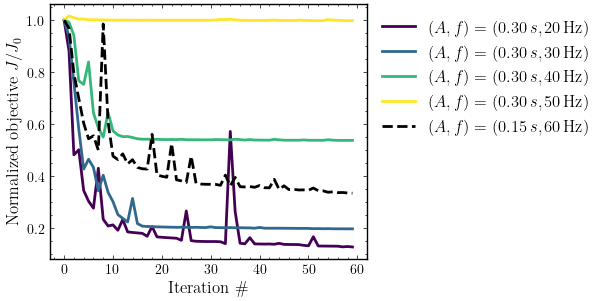

In [14]:
selected_amplitude_frequency_pairs = jnp.array([
    [0.3*optimization.forward_problem.spacing, 20.0],
    [0.3*optimization.forward_problem.spacing, 30.0],
    [0.3*optimization.forward_problem.spacing, 40.0],
    [0.3*optimization.forward_problem.spacing, 50.0],
    [0.3*optimization.forward_problem.spacing/2, 60.0],
])

optimization_filenames = [
    f"opt_with_angle_30_and_length_3_constraints_quads_24x24_amplitude_{a}_initial_angle_{initial_angle*180/jnp.pi:.1f}_amplitude_{a:.2f}_loading_rate_{f:.1f}"
    for a, f in selected_amplitude_frequency_pairs
]

# Compute normalized loss evolution for each optimization
normalized_loss_evolutions = []
for optimization_filename in optimization_filenames:
    opt = OptimizationProblem.from_dict(
        load_data(
            data_folder / optimization_filename / f"{optimization_filename}.pkl"
        )
    )
    normalized_loss_evolutions.append(jnp.array(opt.objective_values) / opt.objective_values[0])

# Plot normalized loss evolutions
max_iterations = 60
line_colors = plt.get_cmap("viridis")(jnp.linspace(0, 1, len(selected_amplitude_frequency_pairs)-1)).tolist()
line_colors = line_colors + ["#000000"]  # Different color for the one at lower amplitude and higher frequency
line_styles = ["-"] * (len(selected_amplitude_frequency_pairs)-1) + ["--"]
fontsize = 12
ticksize = 10
linewidth = 2

plt.close("all")
fig, axes = plt.subplots(figsize=(6, 3), constrained_layout=True)
for (a, f), normalized_loss, color, linestyle in zip(selected_amplitude_frequency_pairs, normalized_loss_evolutions, line_colors, line_styles):
    axes.plot(
        normalized_loss[:max_iterations],
        label=f"$(A,f)=({a/optimization.forward_problem.spacing:.2f}\\,s,{f:.0f}\\,\\text{{Hz}})$",
        linewidth=linewidth,
        color=color,
        linestyle=linestyle,
    )

axes.set_xlabel("Iteration \#", fontsize=fontsize)
axes.set_ylabel("Normalized objective $J/J_0$", fontsize=fontsize)
axes.tick_params(labelsize=ticksize)
axes.grid(False)
axes.legend(
    fontsize=fontsize,
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.0, 1.0),
)
axes.tick_params(labelsize=ticksize)
for spine in axes.spines.values():
    spine.set_linewidth(1.0)

# Save figure
out_path = out_folder / "comparison_optimizations_amplitude_frequency" / f"normalized_loss_evolutions.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(
    out_path,
    dpi=300,
    bbox_inches="tight",
)
# Save pdf version
fig.savefig(
    out_path.with_suffix(".pdf"),
    dpi=300,
    bbox_inches="tight",
)